# Regression Analysis with Regularization

**Name:** Priya Thapa  

**Course:** MSCS 634 – Advanced Big Data and Data Mining

**Instructor:** Dr. Satish Penmatsa

**Lab Assignment:** Regression Techniques and Regularization  

## Objective

The purpose of this lab is to explore different regression techniques using the Diabetes dataset from `sklearn.datasets`. The lab will implement Linear Regression, Multiple Regression, Polynomial Regression, Ridge Regression, and Lasso Regression.

The performance of each model will be evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). Visualizations will also be created to examine data patterns and compare model performance.

### **Step 1: Data Preparation**

### **Loading the Dataset from sklearn.datasets**

The Diabetes dataset is loaded using the `load_diabetes()` function from Scikit-learn. The dataset contains health-related measurements collected from diabetes patients.

The objective is to use these measurements to predict a quantitative measure of diabetes disease progression one year after the initial assessment.

In [2]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Diabetes dataset
from sklearn.datasets import load_diabetes

# Display all DataFrame columns
pd.set_option("display.max_columns", None)

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [3]:
# Load the Diabetes dataset
diabetes = load_diabetes()

# Display the dataset description
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### **Explore Dataset's feature, target values, and data distribution**


In [4]:
# Display the available dataset components
print("Dataset keys:")
print(diabetes.keys())

print("\nFeature names:")
print(diabetes.feature_names)

print("\nShape of the feature data:")
print(diabetes.data.shape)

print("\nShape of the target data:")
print(diabetes.target.shape)

Dataset keys:
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Shape of the feature data:
(442, 10)

Shape of the target data:
(442,)


### Dataset Structure

The Diabetes dataset contains 442 patient observations and 10 numerical input features. Each row represents one patient, while each column represents a health-related measurement.

The target variable is continuous and represents diabetes disease progression. Because the target is numerical rather than categorical, this dataset is suitable for regression analysis.

### Creating a DataFrame

The feature values are converted into a Pandas DataFrame to make the dataset easier to inspect and analyze. The target variable is added as a separate column named `target`.

Each row represents one patient, and each column represents either an input feature or the disease progression target.

In [5]:
# Create a DataFrame using the input features
diabetes_df = pd.DataFrame(
    data=diabetes.data,
    columns=diabetes.feature_names
)

# Add the target variable to the DataFrame
diabetes_df["target"] = diabetes.target

# Display the first five rows
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Dataset Features

The Diabetes dataset contains the following input features:

- **age:** Age of the patient
- **sex:** Sex of the patient
- **bmi:** Body mass index
- **bp:** Average blood pressure
- **s1:** Total serum cholesterol
- **s2:** Low-density lipoproteins
- **s3:** High-density lipoproteins
- **s4:** Total cholesterol divided by high-density lipoproteins
- **s5:** Logarithm of serum triglyceride level
- **s6:** Blood sugar level

The features in the Scikit-learn version of the dataset are already standardized. Therefore, their values are centered around zero and are not displayed in their original measurement units.

### Initial Dataset Inspection

The dataset dimensions, column names, and data types are inspected to verify that the data was loaded correctly.

The `info()` method also helps determine whether any columns contain missing values. All input features and the target variable should appear as numerical data types.

In [6]:
# Display the dimensions of the complete DataFrame
print("Dataset dimensions:", diabetes_df.shape)

# Display column names
print("\nColumn names:")
print(diabetes_df.columns.tolist())

# Display general dataset information
print("\nDataset information:")
diabetes_df.info()

Dataset dimensions: (442, 11)

Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### Descriptive Statistics

Descriptive statistics are calculated for each feature and the target variable. These statistics include:

- Number of observations
- Mean
- Standard deviation
- Minimum value
- Maximum value
- First quartile
- Median
- Third quartile

These values provide an overview of the distributions and ranges of the variables. The feature means are close to zero because the dataset features were standardized before being included in Scikit-learn.

In [7]:
# Display descriptive statistics for all columns
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### Target Variable Distribution

The histogram displays the distribution of the diabetes disease progression target. The kernel density estimate provides a smooth representation of the distribution.

Examining the target distribution helps determine whether the values are evenly distributed, skewed, concentrated within a particular range, or affected by unusual observations.

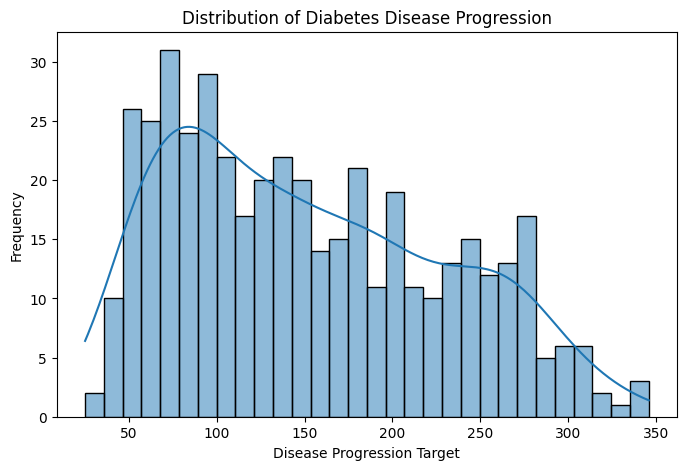

In [10]:
# Create a histogram of the target variable
plt.figure(figsize=(8, 5))

sns.histplot(
    data=diabetes_df,
    x="target",
    bins=30,
    kde=True
)

plt.title("Distribution of Diabetes Disease Progression")
plt.xlabel("Disease Progression Target")
plt.ylabel("Frequency")
plt.show()

### Feature Distributions

Histograms are created for all 10 input features to examine their distributions. These visualizations help identify:

- The general shape of each feature
- Concentrated or widely distributed values
- Possible skewness
- Potential extreme values
- Differences among feature distributions

Because the features are standardized, most values are relatively close to zero.

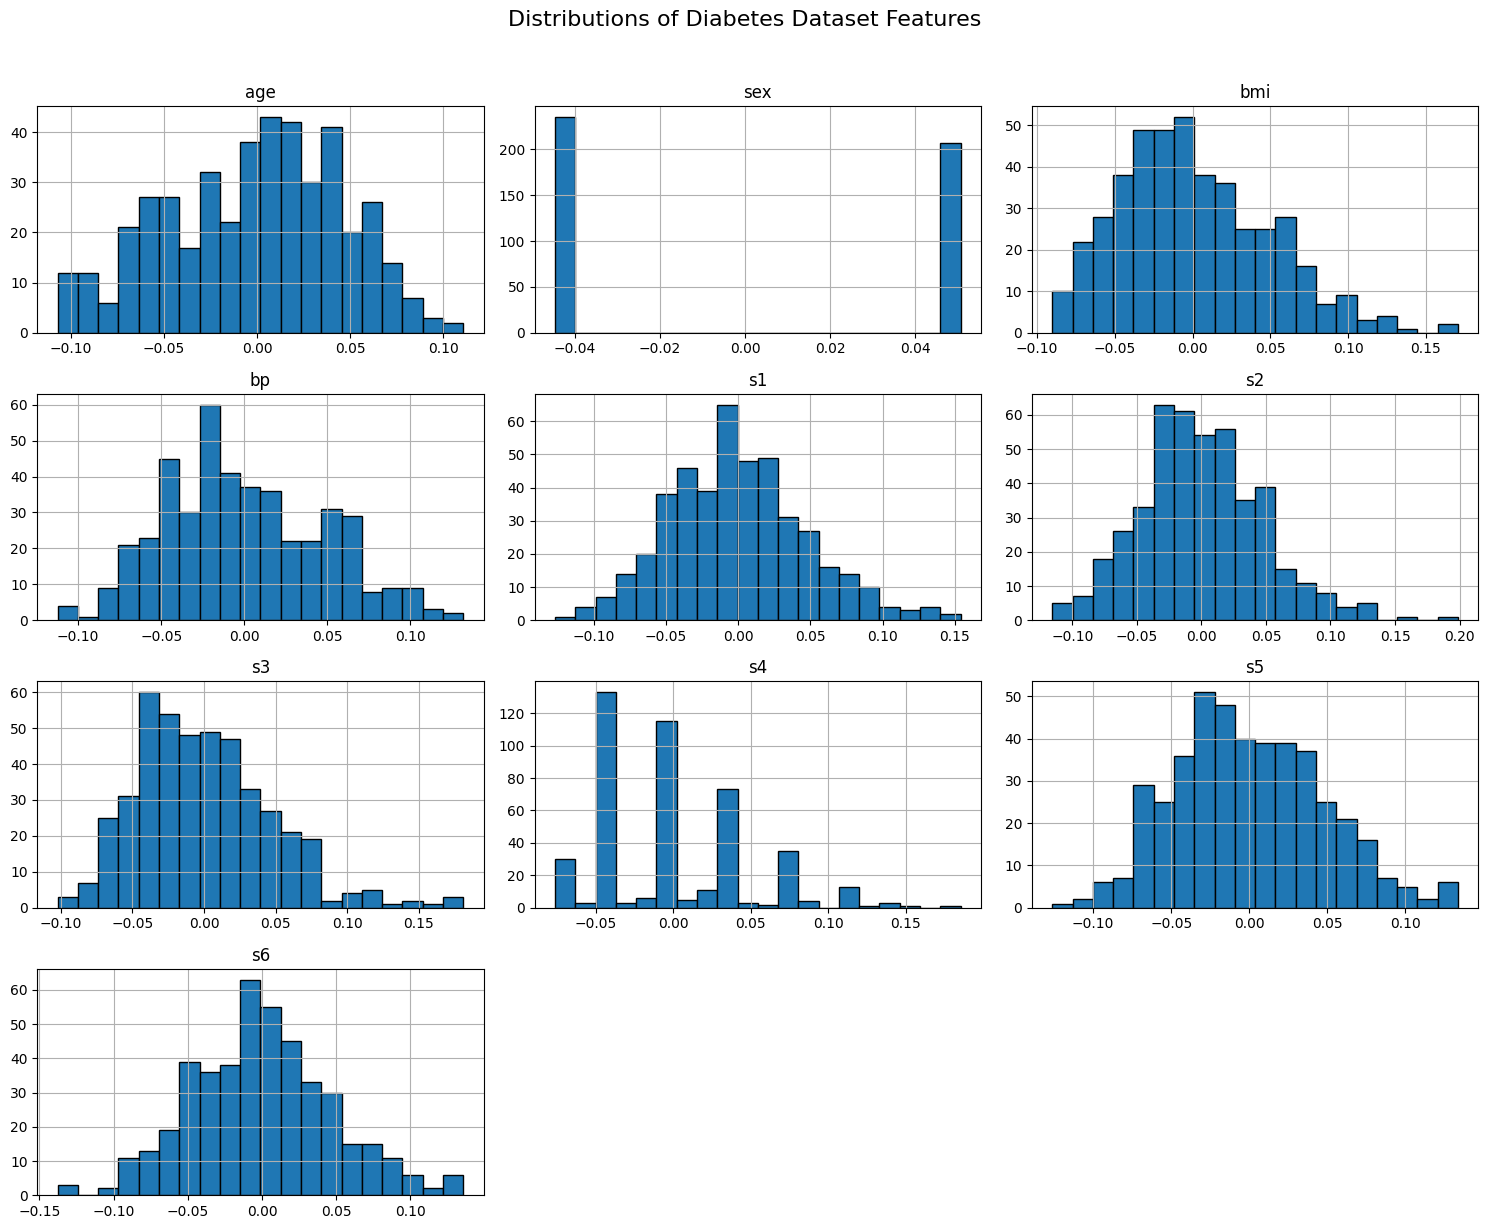

In [11]:
# Select only the input features
feature_columns = diabetes.feature_names

# Create histograms for all features
diabetes_df[feature_columns].hist(
    figsize=(15, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Diabetes Dataset Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Examining Potential Outliers

Boxplots are used to identify observations that fall outside the typical range of each feature. Points beyond the whiskers may represent potential outliers.

However, these observations should not automatically be removed. In a medical dataset, extreme values may represent valid patient conditions rather than data-entry errors. The regression models will first be developed using the complete dataset unless there is strong evidence that an observation is invalid.

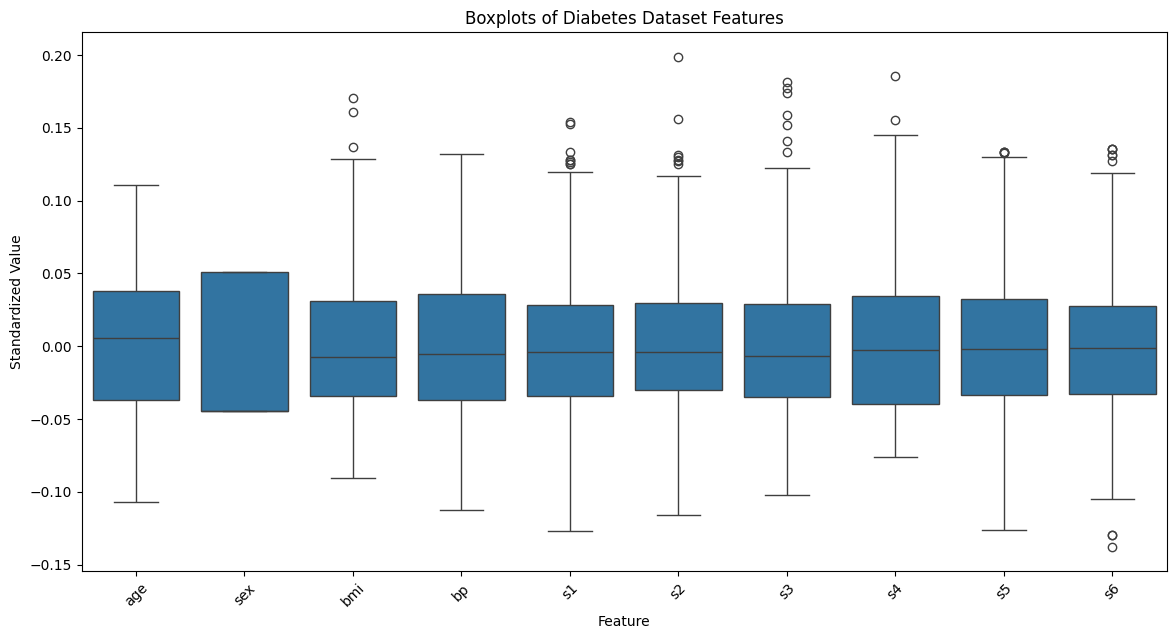

In [12]:
# Reshape the feature data into long format
features_long = diabetes_df[feature_columns].melt(
    var_name="Feature",
    value_name="Value"
)

# Create boxplots for all input features
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=features_long,
    x="Feature",
    y="Value"
)

plt.title("Boxplots of Diabetes Dataset Features")
plt.xlabel("Feature")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.show()

### **Data Cleaning**

### Checking for Missing Values

Missing values are identified using the `isnull()` and `sum()` functions. Missing data can interfere with regression model training and may require removal or imputation.

The Diabetes dataset contains no missing values. Therefore, no missing-value treatment is required before building the regression models.

In [8]:
# Count missing values in each column
missing_values = diabetes_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values: 0


### Checking for Duplicate Records

Duplicate records are checked because repeated observations may introduce bias into the analysis.

The duplicate count shows whether identical rows exist in the dataset. If no duplicate rows are found, no records need to be removed.

In [9]:
# Count duplicate rows
duplicate_count = diabetes_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Check for Datatypes

In [13]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### Data Cleaning Summary

The Diabetes dataset was examined for missing values, duplicate records, incorrect data types, and potential outliers.

- No missing values were found.
- No duplicate records were identified.
- All features were already stored as numerical variables appropriate for regression analysis.


Therefore, no additional data cleaning was necessary before proceeding with regression modeling.

## **Step 2: Simple Linear Regression**

Simple Linear Regression examines the relationship between one independent variable and one continuous dependent variable.

For this model, the **BMI feature** is selected as the independent variable because body mass index is meaningfully related to diabetes progression.

- **Independent variable (X):** BMI
- **Dependent variable (y):** Diabetes disease progression target

### Import Linear Regression and Select the Independent and Dependent Variables

In [15]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Select BMI as the independent variable
X_simple = diabetes_df[["bmi"]]

# Select the target as the dependent variable
y = diabetes_df["target"]

# Display the shapes of X and y
print("Shape of X:", X_simple.shape)
print("Shape of y:", y.shape)

Shape of X: (442, 1)
Shape of y: (442,)


### Create the Linear Regression Model

In [19]:
# Create the Simple Linear Regression model
simple_lr_model = LinearRegression()

### Split the Data Into Training and Testing Sets

The dataset is divided into training and testing sets.

- **80% of the data** is used to train the model.
- **20% of the data** is used to test the model.

The `random_state=42` parameter ensures that the same split is produced each time the notebook is executed.

In [20]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

# Display the dimensions of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 1)
X_test shape: (89, 1)
y_train shape: (353,)
y_test shape: (89,)


### Train and Evaluate the Simple Linear Regression Model

The Simple Linear Regression model is trained using the training data. After training, the model is used to predict diabetes disease progression values for the testing data.

The model's performance is evaluated using:

- **MAE:** Average absolute difference between actual and predicted values.
- **MSE:** Average squared difference between actual and predicted values.
- **RMSE:** Square root of MSE, expressed in the same units as the target variable.
- **R²:** Proportion of variation in the target variable explained by the model.

In [21]:
# Import the required evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train the Simple Linear Regression model
simple_lr_model.fit(X_train, y_train)

# Make predictions using the testing data
y_pred = simple_lr_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the model's performance
print("Simple Linear Regression Evaluation")
print("-----------------------------------")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

Simple Linear Regression Evaluation
-----------------------------------
MAE:  52.26
MSE:  4061.83
RMSE: 63.73
R²:   0.2334


In [22]:
# Display the model coefficient and intercept
print(f"Coefficient: {simple_lr_model.coef_[0]:.2f}")
print(f"Intercept: {simple_lr_model.intercept_:.2f}")

Coefficient: 998.58
Intercept: 152.00


### Visualize the Model's Predictions

A scatter plot is used to compare the actual data with the predictions made by the Simple Linear Regression model.

- **Blue points** represent the actual observations from the testing dataset.
- **Red line** represents the regression model's predicted values.

If the regression line closely follows the pattern of the data points, it indicates that the model captures the relationship between BMI and diabetes disease progression reasonably well.

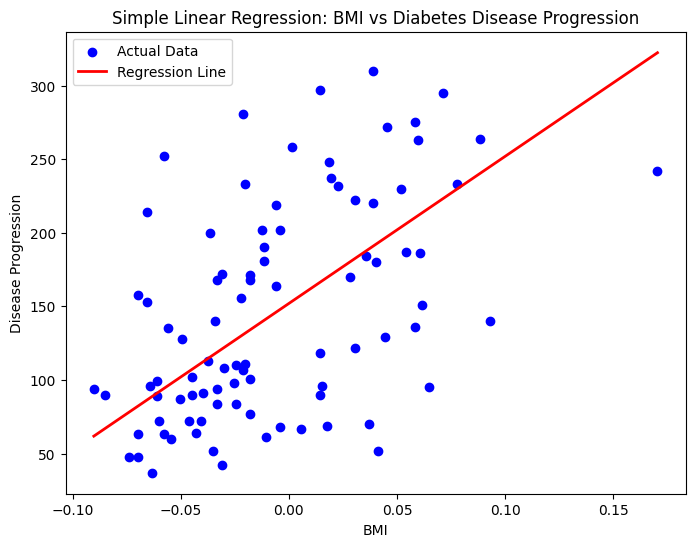

In [23]:
# Create a scatter plot of the actual testing data
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Data"
)

# Sort the test data so the regression line is drawn correctly
sorted_index = X_test["bmi"].argsort()

plt.plot(
    X_test.iloc[sorted_index],
    y_pred[sorted_index],
    color="red",
    linewidth=2,
    label="Regression Line"
)

# Add titles and labels
plt.title("Simple Linear Regression: BMI vs Diabetes Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()

plt.show()

### **Step 3: Multiple Regression**

Multiple Linear Regression predicts a continuous target variable using two or more independent variables.

For this model, all available features in the Diabetes dataset are used as independent variables:

- Age
- Sex
- Body Mass Index (BMI)
- Average Blood Pressure
- Six blood serum measurements: s1, s2, s3, s4, s5, and s6

The dependent variable is the diabetes disease progression target.

Using multiple features allows the model to consider several patient characteristics simultaneously instead of relying only on BMI.

In [24]:
# Select all independent variables
X_multiple = diabetes_df.drop("target", axis=1)

# Select the dependent variable
y = diabetes_df["target"]

# Display the dimensions of the independent and dependent variables
print("Shape of X:", X_multiple.shape)
print("Shape of y:", y.shape)

# Display the first five rows of the independent variables
X_multiple.head()

Shape of X: (442, 10)
Shape of y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Train and Evaluate the Multiple Linear Regression Model

The Multiple Linear Regression model is trained using all ten independent variables in the Diabetes dataset.

The data is divided into:

- **80% training data** to train the model
- **20% testing data** to evaluate the model

The model is evaluated using MAE, MSE, RMSE, and R².

In [25]:
# Import the required functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split the data into training and testing sets
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple,
    y,
    test_size=0.20,
    random_state=42
)

# Create the Multiple Linear Regression model
multiple_lr_model = LinearRegression()

# Train the model using the training data
multiple_lr_model.fit(X_train_multiple, y_train_multiple)

# Make predictions using the testing data
y_pred_multiple = multiple_lr_model.predict(X_test_multiple)

# Calculate the evaluation metrics
mae_multiple = mean_absolute_error(y_test_multiple, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

# Display the results
print("Multiple Linear Regression Evaluation")
print("-------------------------------------")
print(f"MAE:  {mae_multiple:.2f}")
print(f"MSE:  {mse_multiple:.2f}")
print(f"RMSE: {rmse_multiple:.2f}")
print(f"R²:   {r2_multiple:.4f}")

Multiple Linear Regression Evaluation
-------------------------------------
MAE:  42.79
MSE:  2900.19
RMSE: 53.85
R²:   0.4526


### Visualize the Predicted Values Versus the Actual Values

A scatter plot is used to compare the actual diabetes disease progression values with the values predicted by the Multiple Linear Regression model.

- Each point represents one observation from the testing dataset.
- The red dashed line represents the ideal case where the predicted values are exactly equal to the actual values.
- Points closer to the diagonal line indicate more accurate predictions.

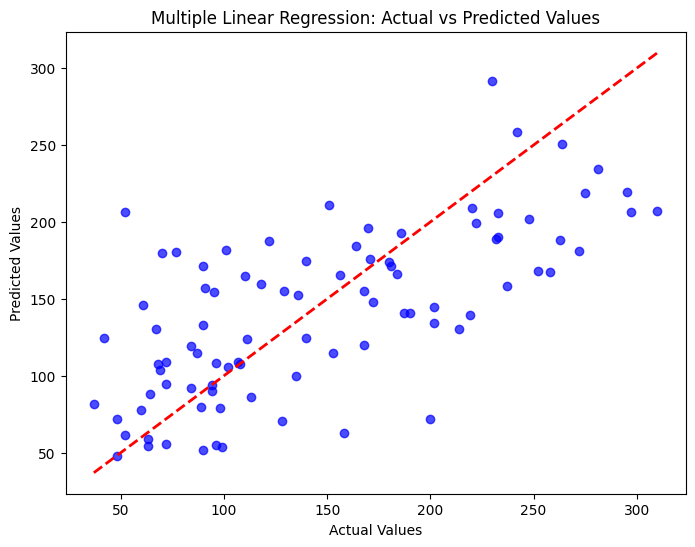

In [26]:
# Visualize the predicted values versus the actual values
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test_multiple,
    y_pred_multiple,
    color="blue",
    alpha=0.7
)

# Plot the ideal prediction line
plt.plot(
    [y_test_multiple.min(), y_test_multiple.max()],
    [y_test_multiple.min(), y_test_multiple.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

# Add title and labels
plt.title("Multiple Linear Regression: Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

## **Step 4: Polynomial Regression**

Polynomial Regression extends Linear Regression by adding polynomial terms of the independent variable. This allows the model to capture nonlinear relationships between the predictor and the target variable.

For this model:

- Independent variable: BMI
- Dependent variable: Diabetes disease progression target
- Polynomial degree: 2

A second-degree polynomial is used to determine whether a curved relationship better represents the data than a straight line.

In [27]:
# Import the required libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Select BMI as the independent variable
X_poly = diabetes_df[["bmi"]]
y = diabetes_df["target"]

# Create polynomial features of degree 2
poly = PolynomialFeatures(degree=2)

X_poly_features = poly.fit_transform(X_poly)

# Display the first few transformed rows
print("Original shape:", X_poly.shape)
print("Polynomial feature shape:", X_poly_features.shape)

X_poly_features[:5]

Original shape: (442, 1)
Polynomial feature shape: (442, 3)


array([[ 1.00000000e+00,  6.16962065e-02,  3.80642190e-03],
       [ 1.00000000e+00, -5.14740612e-02,  2.64957898e-03],
       [ 1.00000000e+00,  4.44512133e-02,  1.97591037e-03],
       [ 1.00000000e+00, -1.15950145e-02,  1.34444361e-04],
       [ 1.00000000e+00, -3.63846922e-02,  1.32384583e-03]])

### Train and Evaluate the Polynomial Regression Model

The BMI data is divided into 80% training data and 20% testing data. Second-degree polynomial features are then created from BMI.

The polynomial transformer is fitted only to the training data and subsequently applied to the testing data. This prevents information from the testing set from influencing model training.

The Polynomial Regression model is evaluated using MAE, MSE, RMSE, and R². Its results are then compared with the Simple Linear Regression and Multiple Linear Regression models.

In [28]:
# Split the original BMI data before creating polynomial features
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y,
    test_size=0.20,
    random_state=42
)

# Create second-degree polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit the transformer on the training data and transform it
X_train_poly_transformed = poly.fit_transform(X_train_poly)

# Transform the testing data using the fitted transformer
X_test_poly_transformed = poly.transform(X_test_poly)

# Create and train the Polynomial Regression model
polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly_transformed, y_train_poly)

# Make predictions on the testing data
y_pred_poly = polynomial_model.predict(X_test_poly_transformed)

# Calculate evaluation metrics
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

# Display the Polynomial Regression results
print("Polynomial Regression Evaluation")
print("--------------------------------")
print(f"MAE:  {mae_poly:.2f}")
print(f"MSE:  {mse_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R²:   {r2_poly:.4f}")

Polynomial Regression Evaluation
--------------------------------
MAE:  52.38
MSE:  4085.03
RMSE: 63.91
R²:   0.2290


### Compare all three models

In [29]:
# Create a table comparing the three regression models
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly
    ],
    "MSE": [
        mse,
        mse_multiple,
        mse_poly
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly
    ],
    "R²": [
        r2,
        r2_multiple,
        r2_poly
    ]
})

# Round the values for readability
model_comparison = model_comparison.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4
})

model_comparison

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,52.26,4061.83,63.73,0.2334
1,Multiple Linear Regression,42.79,2900.19,53.85,0.4526
2,Polynomial Regression,52.38,4085.03,63.91,0.2290


### Model Comparison Analysis

The Multiple Linear Regression model achieved the best overall performance among the three models. It produced the lowest MAE, MSE, and RMSE values, indicating that its predictions were closer to the actual diabetes progression values. It also achieved the highest R² score of 0.4526, meaning that it explained approximately 45.26% of the variation in the target variable.

The Simple Linear Regression model and Polynomial Regression model produced very similar results because both models used BMI as the only independent variable. The Polynomial Regression model had a slightly higher MAE, MSE, and RMSE and a slightly lower R² score than the Simple Linear Regression model.

Therefore, adding the squared BMI feature did not improve the model. The Multiple Linear Regression model performed better because it used all ten patient characteristics, allowing it to capture more information related to diabetes disease progression.

### Demonstrating Underfitting and Overfitting

### Effect of Polynomial Degree on Underfitting and Overfitting

Polynomial degree controls the complexity of the regression model.

- A low-degree model may be too simple to capture the underlying relationship, resulting in underfitting.
- A moderate-degree model may capture the relationship without becoming unnecessarily complex.
- A high-degree model may fit small fluctuations or noise in the training data, resulting in overfitting.

To demonstrate this effect, Polynomial Regression models are trained using degrees 1, 2, 3, 5, 10, and 15. The training and testing RMSE and R² values are compared for each degree.

### Train models using different polynomial degrees

In [30]:
# Import Pipeline to combine polynomial transformation and regression
from sklearn.pipeline import Pipeline

# Polynomial degrees to test
degrees = [1, 2, 3, 5, 10, 15]

# Lists for storing model results
degree_results = []

for degree in degrees:

    # Create a pipeline that generates polynomial features
    # and trains a Linear Regression model
    polynomial_pipeline = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(degree=degree, include_bias=False)
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    # Train the model
    polynomial_pipeline.fit(X_train_poly, y_train_poly)

    # Make predictions for training and testing data
    y_train_pred_degree = polynomial_pipeline.predict(X_train_poly)
    y_test_pred_degree = polynomial_pipeline.predict(X_test_poly)

    # Calculate training metrics
    train_mse = mean_squared_error(
        y_train_poly,
        y_train_pred_degree
    )

    train_rmse = np.sqrt(train_mse)

    train_r2 = r2_score(
        y_train_poly,
        y_train_pred_degree
    )

    # Calculate testing metrics
    test_mse = mean_squared_error(
        y_test_poly,
        y_test_pred_degree
    )

    test_rmse = np.sqrt(test_mse)

    test_r2 = r2_score(
        y_test_poly,
        y_test_pred_degree
    )

    # Store the results
    degree_results.append({
        "Degree": degree,
        "Training RMSE": train_rmse,
        "Testing RMSE": test_rmse,
        "Training R²": train_r2,
        "Testing R²": test_r2
    })

# Convert the results into a DataFrame
degree_comparison = pd.DataFrame(degree_results)

# Round the values for readability
degree_comparison = degree_comparison.round({
    "Training RMSE": 2,
    "Testing RMSE": 2,
    "Training R²": 4,
    "Testing R²": 4
})

degree_comparison

,Degree,Training RMSE,Testing RMSE,Training R²,Testing R²
0,1,62.08,63.73,0.3657,0.2334
1,2,62.04,63.91,0.3665,0.2290
2,3,62.04,63.75,0.3667,0.2329
3,5,61.84,63.92,0.3707,0.2288
4,10,61.03,65.69,0.3870,0.1855
5,15,60.89,174.33,0.3897,-4.7362


### Visualize training and testing RMSE

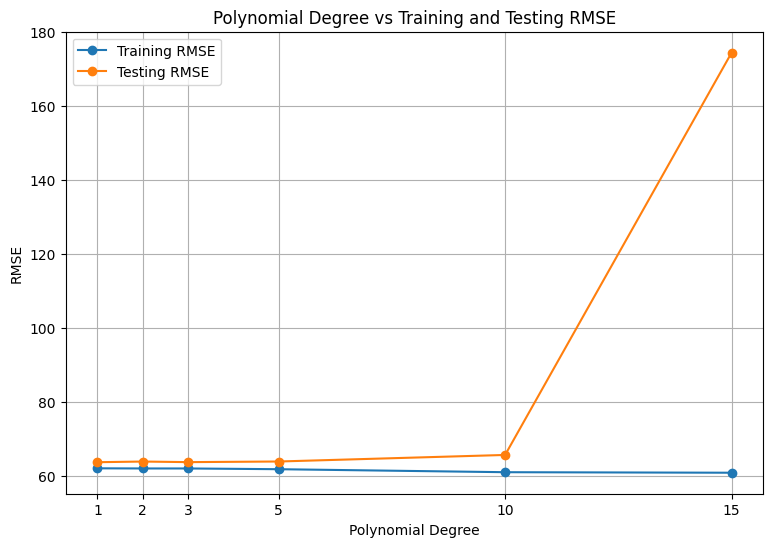

In [31]:
# Plot training and testing RMSE by polynomial degree
plt.figure(figsize=(9, 6))

plt.plot(
    degree_comparison["Degree"],
    degree_comparison["Training RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    degree_comparison["Degree"],
    degree_comparison["Testing RMSE"],
    marker="o",
    label="Testing RMSE"
)

plt.title("Polynomial Degree vs Training and Testing RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

### Visualize training and testing R²

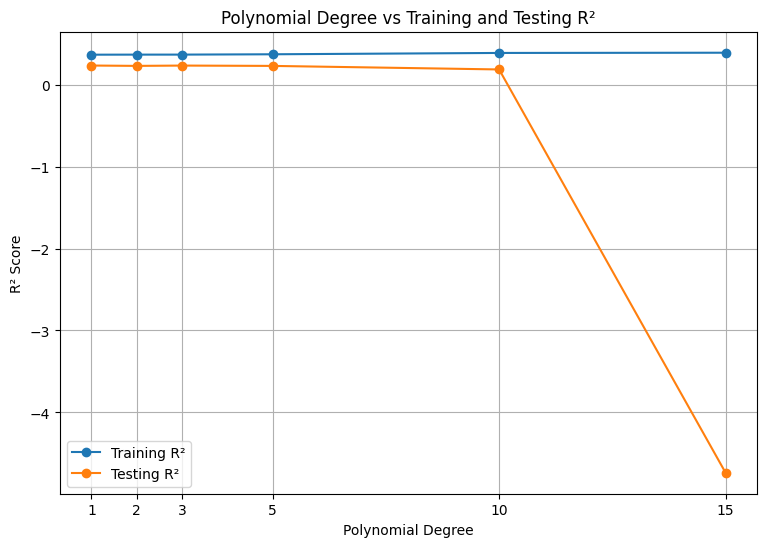

In [32]:
# Plot training and testing R² by polynomial degree
plt.figure(figsize=(9, 6))

plt.plot(
    degree_comparison["Degree"],
    degree_comparison["Training R²"],
    marker="o",
    label="Training R²"
)

plt.plot(
    degree_comparison["Degree"],
    degree_comparison["Testing R²"],
    marker="o",
    label="Testing R²"
)

plt.title("Polynomial Degree vs Training and Testing R²")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

### Analysis of Underfitting and Overfitting

A degree-1 model is equivalent to Simple Linear Regression. Because it only fits a straight line, it may underfit if the relationship between BMI and diabetes progression contains meaningful curvature.

Increasing the degree gives the model greater flexibility. A moderate-degree model can potentially capture nonlinear patterns that a straight line cannot represent.

However, as the degree becomes very high, the model may begin fitting random fluctuations and noise in the training data. This can be identified when:

- Training RMSE continues to decrease.
- Training R² continues to increase.
- Testing RMSE increases.
- Testing R² decreases or becomes negative.
- A large performance gap appears between the training and testing sets.

This pattern indicates overfitting because the model performs well on data it has already seen but does not generalize well to new observations.

For this dataset, increasing the polynomial degree does not necessarily improve testing performance. The degree-2 model already performed slightly worse than the degree-1 model, suggesting that the relationship between BMI and disease progression does not benefit significantly from additional polynomial complexity.

## **Step 5: Regularization with Ridge and Lasso Regression**

Regularization is used to reduce overfitting by adding a penalty to the Linear Regression model.

Two regularization techniques are implemented:

- **Ridge Regression:** Uses L2 regularization and reduces the magnitude of coefficients without usually making them exactly zero.
- **Lasso Regression:** Uses L1 regularization and can reduce some coefficients to exactly zero, allowing it to perform feature selection.

Both models use all ten independent variables from the Diabetes dataset. Feature scaling is applied before training because Ridge and Lasso are affected by the scale of the independent variables.

In [33]:
# Import Ridge, Lasso, StandardScaler, and Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Implement Ridge Regression

In [34]:
# Create a Ridge Regression pipeline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Train the Ridge Regression model
ridge_model.fit(
    X_train_multiple,
    y_train_multiple
)

# Make predictions using the testing data
y_pred_ridge = ridge_model.predict(X_test_multiple)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Implement Lasso Regression

In [35]:
# Create a Lasso Regression pipeline
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, max_iter=10000))
])

# Train the Lasso Regression model
lasso_model.fit(
    X_train_multiple,
    y_train_multiple
)

# Make predictions using the testing data
y_pred_lasso = lasso_model.predict(X_test_multiple)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


### Verify the predictions

In [36]:
# Display the first five Ridge predictions
print("First five Ridge predictions:")
print(y_pred_ridge[:5])

# Display the first five Lasso predictions
print("\nFirst five Lasso predictions:")
print(y_pred_lasso[:5])

First five Ridge predictions:
[139.86277405 179.9582406  135.71687469 292.11578228 123.18931464]

First five Lasso predictions:
[144.57023028 178.81110506 146.73567504 280.88957847 124.03909694]


### Train and Evaluate Ridge and Lasso Regression Models

The Ridge and Lasso Regression models are evaluated using the same metrics as the previous regression models:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The results are then compared with the Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression models.

### Evaluate Ridge Regression

In [37]:
# Calculate Ridge Regression evaluation metrics
mae_ridge = mean_absolute_error(y_test_multiple, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_multiple, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_multiple, y_pred_ridge)

print("Ridge Regression Evaluation")
print("---------------------------")
print(f"MAE:  {mae_ridge:.2f}")
print(f"MSE:  {mse_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²:   {r2_ridge:.4f}")

Ridge Regression Evaluation
---------------------------
MAE:  42.81
MSE:  2892.01
RMSE: 53.78
R²:   0.4541


### Evaluate Lasso Regression

In [38]:
# Calculate Lasso Regression evaluation metrics
mae_lasso = mean_absolute_error(y_test_multiple, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_multiple, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_multiple, y_pred_lasso)

print("\nLasso Regression Evaluation")
print("---------------------------")
print(f"MAE:  {mae_lasso:.2f}")
print(f"MSE:  {mse_lasso:.2f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"R²:   {r2_lasso:.4f}")


Lasso Regression Evaluation
---------------------------
MAE:  42.80
MSE:  2824.57
RMSE: 53.15
R²:   0.4669


### Comparison to other Regression models

In [39]:
# Create a comparison table for all regression models
comparison_table = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly,
        mae_ridge,
        mae_lasso
    ],
    "MSE": [
        mse,
        mse_multiple,
        mse_poly,
        mse_ridge,
        mse_lasso
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly,
        rmse_ridge,
        rmse_lasso
    ],
    "R²": [
        r2,
        r2_multiple,
        r2_poly,
        r2_ridge,
        r2_lasso
    ]
})

# Round values for readability
comparison_table = comparison_table.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4
})

comparison_table

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,52.26,4061.83,63.73,0.2334
1,Multiple Linear Regression,42.79,2900.19,53.85,0.4526
2,Polynomial Regression,52.38,4085.03,63.91,0.2290
3,Ridge Regression,42.81,2892.01,53.78,0.4541
4,Lasso Regression,42.80,2824.57,53.15,0.4669


### Comparison of Regression Models

The Multiple Linear Regression, Ridge Regression, and Lasso Regression models achieved the best overall performance. All three models produced substantially lower MAE, MSE, and RMSE values than the Simple Linear Regression and Polynomial Regression models.

Ridge Regression and Lasso Regression produced performance that was very similar to Multiple Linear Regression. This indicates that regularization did not significantly improve prediction accuracy for this dataset. However, regularization can help reduce overfitting and improve model stability when datasets contain highly correlated features or a large number of variables.

The Polynomial Regression model performed slightly worse than the Simple Linear Regression model because adding a second-degree BMI feature did not capture additional useful information. In contrast, the models that used all ten patient characteristics consistently produced better predictions.

Overall, the Multiple Linear Regression, Ridge Regression, and Lasso Regression models were the most effective approaches for predicting diabetes disease progression on this dataset.

### Effect of the Regularization Parameter (Alpha)

The **alpha** parameter controls the strength of regularization in both Ridge Regression and Lasso Regression.

- **Small alpha values (close to 0):**
  - Apply little or no regularization.
  - The model behaves similarly to ordinary Multiple Linear Regression.
  - Coefficients remain relatively large.
  - The model may overfit the training data if unnecessary complexity exists.

- **Moderate alpha values:**
  - Apply a balanced amount of regularization.
  - Coefficients are reduced, helping improve model stability.
  - The model often generalizes better to unseen data by reducing overfitting.

- **Large alpha values:**
  - Apply strong regularization.
  - Coefficients become much smaller.
  - Ridge Regression shrinks coefficients toward zero but typically does not eliminate them completely.
  - Lasso Regression can reduce some coefficients exactly to zero, effectively removing less important features from the model.
  - If alpha becomes excessively large, the model may underfit the data, leading to lower prediction accuracy.

In this project, an **alpha value of 1.0** was used for both Ridge and Lasso Regression. The Ridge and Lasso models produced performance that was very similar to the Multiple Linear Regression model, indicating that the original model was already well generalized and did not suffer from significant overfitting. The regularization techniques helped control model complexity without substantially changing prediction performance.

### Visualize Ridge and Lasso Regression Predictions

The scatter plot compares the actual diabetes disease progression values with the values predicted by the Ridge Regression and Lasso Regression models.

- **Blue points** represent Ridge Regression predictions.
- **Green points** represent Lasso Regression predictions.
- **Red dashed line** represents the ideal case where the predicted values exactly match the actual values.

Points that lie closer to the red dashed line indicate more accurate predictions.

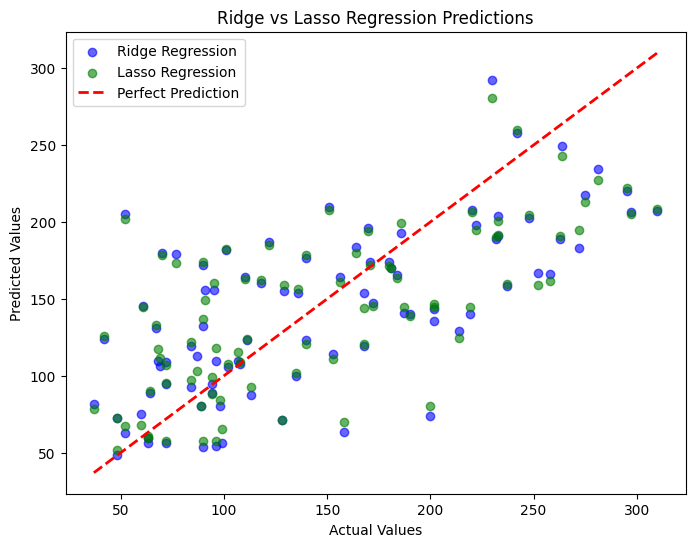

In [40]:
# Visualize Ridge and Lasso predictions
plt.figure(figsize=(8, 6))

# Ridge predictions
plt.scatter(
    y_test_multiple,
    y_pred_ridge,
    color="blue",
    alpha=0.6,
    label="Ridge Regression"
)

# Lasso predictions
plt.scatter(
    y_test_multiple,
    y_pred_lasso,
    color="green",
    alpha=0.6,
    label="Lasso Regression"
)

# Ideal prediction line
plt.plot(
    [y_test_multiple.min(), y_test_multiple.max()],
    [y_test_multiple.min(), y_test_multiple.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

# Labels and title
plt.title("Ridge vs Lasso Regression Predictions")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

plt.show()

### **Step 6: Model Comparison and Analysis**

The performance of the five regression models is compared using the following evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

These metrics provide a comprehensive assessment of each model's prediction accuracy and goodness of fit.

In [41]:
# Final comparison of all regression models
final_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly,
        mae_ridge,
        mae_lasso
    ],
    "MSE": [
        mse,
        mse_multiple,
        mse_poly,
        mse_ridge,
        mse_lasso
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly,
        rmse_ridge,
        rmse_lasso
    ],
    "R²": [
        r2,
        r2_multiple,
        r2_poly,
        r2_ridge,
        r2_lasso
    ]
})

# Round values for easier reading
final_comparison = final_comparison.round(2)

final_comparison

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,52.26,4061.83,63.73,0.23
1,Multiple Linear Regression,42.79,2900.19,53.85,0.45
2,Polynomial Regression,52.38,4085.03,63.91,0.23
3,Ridge Regression,42.81,2892.01,53.78,0.45
4,Lasso Regression,42.80,2824.57,53.15,0.47


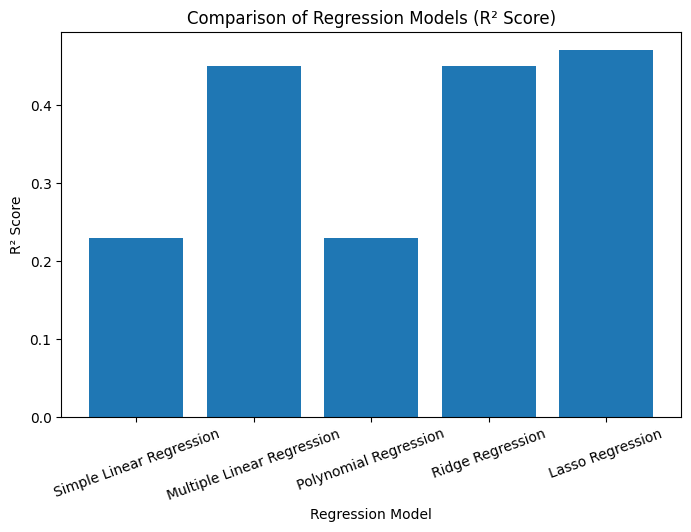

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    final_comparison["Model"],
    final_comparison["R²"]
)

plt.title("Comparison of Regression Models (R² Score)")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

## Discussion and Key Observations

### Performance of Each Regression Model

The five regression models demonstrated varying levels of predictive performance on the Diabetes dataset. The Simple Linear Regression model achieved the lowest performance because it used only BMI as the independent variable. While BMI is an important indicator of diabetes progression, relying on a single feature limited the model's ability to explain the variation in the target variable, resulting in higher prediction errors and a lower R² score.

The Multiple Linear Regression model significantly improved prediction accuracy by using all ten available features in the dataset. It achieved much lower MAE, MSE, and RMSE values while producing the highest R² score, indicating that incorporating additional patient information allowed the model to better capture the relationship between the predictors and diabetes disease progression.

The Polynomial Regression model did not improve performance over the Simple Linear Regression model. Although polynomial features allow the model to capture nonlinear relationships, applying a second-degree transformation to BMI alone did not provide additional predictive power. The model produced slightly higher prediction errors and a slightly lower R² score, suggesting that the relationship between BMI and disease progression is not sufficiently nonlinear to justify the added complexity.

The Ridge Regression and Lasso Regression models produced performance that was nearly identical to the Multiple Linear Regression model. Their evaluation metrics were very similar, demonstrating that adding regularization did not substantially change prediction accuracy for this dataset.

### Models that Addressed Overfitting

Regularization techniques are primarily designed to reduce overfitting by controlling model complexity. Ridge Regression applies L2 regularization, which shrinks the magnitude of all coefficients while retaining every feature in the model. Lasso Regression applies L1 regularization, which can shrink some coefficients to zero, effectively performing automatic feature selection.

In this project, both Ridge and Lasso Regression showed nearly the same predictive performance as the Multiple Linear Regression model. This indicates that the original multiple regression model was already well generalized and did not exhibit significant overfitting. While regularization did not noticeably improve the evaluation metrics, it still provided additional protection against overfitting and improved model stability.

### Insights Gained from the Diabetes Dataset

Several important insights were gained from analyzing the Diabetes dataset. First, using multiple patient characteristics produced substantially better predictions than relying on BMI alone, demonstrating that diabetes progression is influenced by several clinical factors rather than a single measurement.

Second, increasing model complexity does not always improve predictive performance. The Polynomial Regression model introduced additional complexity but did not outperform the simpler linear model, illustrating that more complex models are not necessarily better when the underlying relationships are relatively linear.

Finally, the similar performance of Multiple Linear Regression, Ridge Regression, and Lasso Regression suggests that the dataset is well structured and does not suffer from severe overfitting. Overall, the analysis demonstrates the importance of selecting an appropriate model based on both prediction accuracy and model complexity, while highlighting the value of regularization techniques for improving model robustness in regression problems.